In [1]:
import pandas as pd
import geopandas as gpd

print("🚀 Ready to explore urban mobility in Beijing")

🚀 Ready to explore urban mobility in Beijing


In [2]:
from  google.colab import files
uploades = files.upload()

Saving beijing_bus_routes.zip to beijing_bus_routes.zip


In [3]:
!unzip beijing_bus_routes.zip

Archive:  beijing_bus_routes.zip
  inflating: beijing_bus_routes.cpg  
  inflating: beijing_bus_routes.dbf  
  inflating: beijing_bus_routes.prj  
  inflating: beijing_bus_routes.shp  
  inflating: beijing_bus_routes.shx  


In [6]:
import os
os.listdir()

['.config',
 'beijing_bus_routes.prj',
 'beijing_bus_routes.zip',
 'beijing_bus_routes.dbf',
 'beijing_bus_routes.shp',
 'beijing_bus_routes.shx',
 'beijing_bus_routes.cpg',
 'sample_data']

In [8]:
df = gpd.read_file('beijing_bus_routes.shp')
df.head()

,route_cn,route_en,city_code,route_type,company_cn,company_en,s_stop_cn,s_stop_en,e_stop_cn,e_stop_en,...,end_time,loop,status,basic_prc,total_prc,city_cn,city_en,type_en,length,geometry
0,郊82路(小渔阳站--汽车站),Suburban 82 Road (Xiaoyuyang Station - Bus Sta...,010,普通公交,北京市宝城客运有限责任公司,"Beijing Baocheng Passenger Transport Co., Ltd",小渔阳站,Xiaoyuyang Station,汽车站,bus stop,...,1700,0,1,2,11,北京,Beijing,Regular buses,46.895,"LINESTRING (117.10453 40.15289, 117.10454 40.1..."
1,兴14路(化纤俱乐部区间)(化纤俱乐部--一品嘉园),Xing 14 Road (Chemical Fiber Club Section)(Che...,010,普通公交,北京新国线客运有限公司;北京京汉运输公司,Beijing New National Line Passenger Transport ...,化纤俱乐部,Synthetic Fiber Club,一品嘉园,Yipin Jiayuan,...,None,0,1,2,2,北京,Beijing,Regular buses,17.452,"LINESTRING (116.3263 39.73499, 116.3263 39.734..."
2,485路(北京南站--振亚庄),Bus No. 485 (Beijing South Railway Station - Z...,010,普通公交,北京公共交通控股集团有限公司第三客运分公司,The Third Passenger Transport Branch of Beijin...,北京南站,Beijing South Railway Station,振亚庄,Zhenyazhuang,...,2300,0,1,2,5,北京,Beijing,Regular buses,19.090,"LINESTRING (116.37046 39.86626, 116.36977 39.8..."
3,休闲观光专线5路(德胜门--八达岭夜长城),Leisure and sightseeing line No. 5 (Deshengmen...,010,旅游专线,None,None,德胜门,Desheng Gate,八达岭夜长城,Badaling Night Great Wall,...,None,0,0,42,42,北京,Beijing,Tourist line,58.060,"LINESTRING (116.37274 39.94858, 116.37262 39.9..."
4,481路(紫竹院北门--吴庄公交场站),Bus No. 481 (North Gate of Zizhuyuan - Wuzhuan...,010,普通公交,北京公交集团,Beijing Public Transport Group,紫竹院北门,The north gate of Zizhuyuan,吴庄公交场站,Wuzhuang Bus Station,...,None,0,1,2,4,北京,Beijing,Regular buses,18.121,"LINESTRING (116.31242 39.94459, 116.31424 39.9..."


In [9]:
print(df.shape)
print(df.columns)
df.info()

(4137, 23)
Index(['route_cn', 'route_en', 'city_code', 'route_type', 'company_cn',
       'company_en', 's_stop_cn', 's_stop_en', 'e_stop_cn', 'e_stop_en',
       'distance', 'total_stop', 'start_time', 'end_time', 'loop', 'status',
       'basic_prc', 'total_prc', 'city_cn', 'city_en', 'type_en', 'length',
       'geometry'],
      dtype='object')
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 4137 entries, 0 to 4136
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   route_cn    4137 non-null   object  
 1   route_en    4137 non-null   object  
 2   city_code   4137 non-null   object  
 3   route_type  4137 non-null   object  
 4   company_cn  3451 non-null   object  
 5   company_en  3451 non-null   object  
 6   s_stop_cn   4137 non-null   object  
 7   s_stop_en   4137 non-null   object  
 8   e_stop_cn   4137 non-null   object  
 9   e_stop_en   4137 non-null   object  
 10  distance    4137 non-null

In [10]:
df = df[['length', 'start_time', 'end_time']].copy()
df.head()

,length,start_time,end_time
0,46.895,0630,1700
1,17.452,None,None
2,19.090,0630,2300
3,58.060,None,None
4,18.121,None,None


In [17]:
df['start_time'] = pd.to_numeric(df['start_time'], errors='coerce')
df['end_time'] = pd.to_numeric(df['end_time'], errors='coerce')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4137 entries, 0 to 4136
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   length      4137 non-null   float64
 1   start_time  1515 non-null   float64
 2   end_time    1515 non-null   float64
dtypes: float64(3)
memory usage: 97.1 KB


,length,start_time,end_time
0,46.895,630.0,1700.0
1,17.452,NaN,NaN
2,19.090,630.0,2300.0
3,58.060,NaN,NaN
4,18.121,NaN,NaN


### 🔍 What I’m Trying to Understand

I want to understand how long bus routes typically operate within a day.

Are most routes short-lived, or do they run for most of the day?

To answer this, I calculate the operating duration using:
(end_time - start_time)

In [18]:
df['operating_hours'] = (df['end_time'] - df['start_time'])/100

In [19]:
df[['start_time', 'end_time', 'operating_hours']].head()

,start_time,end_time,operating_hours
0,630.0,1700.0,10.7
1,NaN,NaN,NaN
2,630.0,2300.0,16.7
3,NaN,NaN,NaN
4,NaN,NaN,NaN


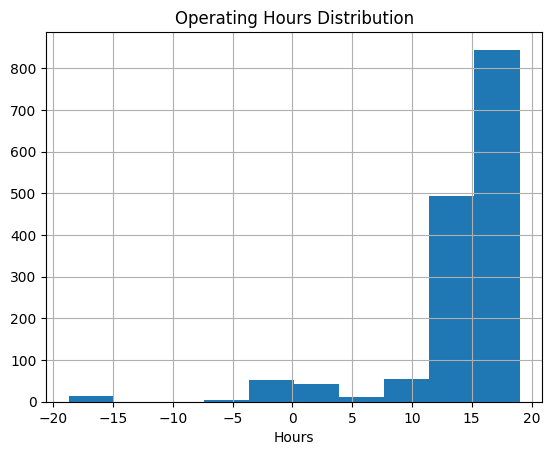

In [22]:
import matplotlib.pyplot as plt

df['operating_hours'].hist()
plt.title("Operating Hours Distribution")
plt.xlabel("Hours")
plt.show()

### ⚠️ Unexpected Result

After plotting the distribution, I noticed something unusual:
some operating durations are negative.

This doesn’t make sense at first glance — how can a route operate for negative hours?

This led me to question:
- Is the data incorrect?
- Or is my calculation too simplistic?

### 🧠 Reasoning

At first, I assumed:
end_time should always be greater than start_time.

But then I realized:
this assumption only works if all routes operate within the same day.

In reality, some routes may operate overnight.

For example:
- Start: 17:00
- End: 06:00 (next day)

Using a simple subtraction:
600 - 1700 = negative value

So the issue is not necessarily the data —
it’s the limitation of the current calculation.

In [23]:
df = df.dropna(subset=['start_time', 'end_time'])

In [25]:
df = df[df['end_time'] > df['start_time']]

In [26]:
df = df[(df['end_time'] - df['start_time']) <= 2400]

In [27]:
df['operating_hours'] = (df['end_time'] - df['start_time']) / 100

In [28]:
df[['start_time','end_time','operating_hours']].head()

,start_time,end_time,operating_hours
0,630.0,1700.0,10.7
2,630.0,2300.0,16.7
7,630.0,2200.0,15.7
8,600.0,1910.0,13.1
12,530.0,2200.0,16.7


### ⚙️ Current Approach

To proceed with the analysis, I applied the following filters:

1. Remove rows with missing time values  
2. Keep only cases where end_time > start_time  
3. Limit duration to within 24 hours  

This effectively assumes:
- All routes operate within the same day  
- Overnight routes are excluded  

This is a simplification, not a perfect representation of reality.

### ⚠️ Important Limitation

By applying these filters, I am excluding:
routes that operate past midnight.

This means:
the analysis does not capture late-night transport behavior.

So the results should be interpreted as:
→ “same-day operating patterns only”

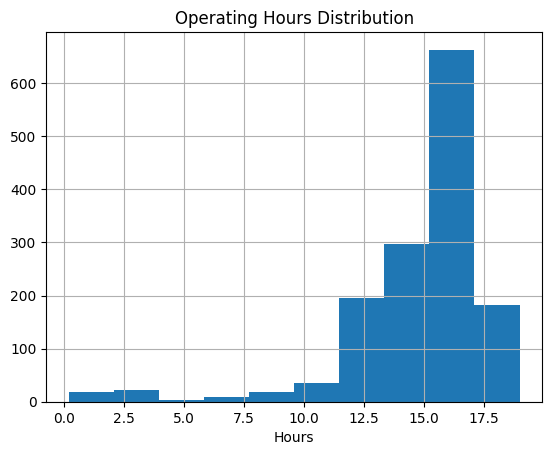

,operating_hours
count,1446.000000
mean,14.918375
std,3.068716
min,0.200000
25%,13.912500
50%,15.950000
75%,16.900000
max,19.000000


In [29]:
df['operating_hours'].hist()
plt.title("Operating Hours Distribution")
plt.xlabel("Hours")
plt.show()
df['operating_hours'].describe()

### 🤔 Reflection

At this point, I questioned whether this cleaning step is biased.

Am I removing data just to make the results look better?

After thinking about it, I realized:

This is not about making the data look good —
it’s about ensuring the calculation is valid under the current model.

However, this also means:
I am choosing a simpler model over a more accurate one.

This trade-off should be acknowledged.

### 📊 Result

With the simplified assumptions applied,
the distribution now shows that:

- Most routes operate between ~14–17 hours  
- Very few routes operate for short durations  

This suggests that the transport system is active for most of the day.

### 🔄 Next Improvement

A better approach would be:

- Handle overnight routes properly  
- Adjust time calculation to account for cross-day operations  

This will be explored in the next phase of the project.

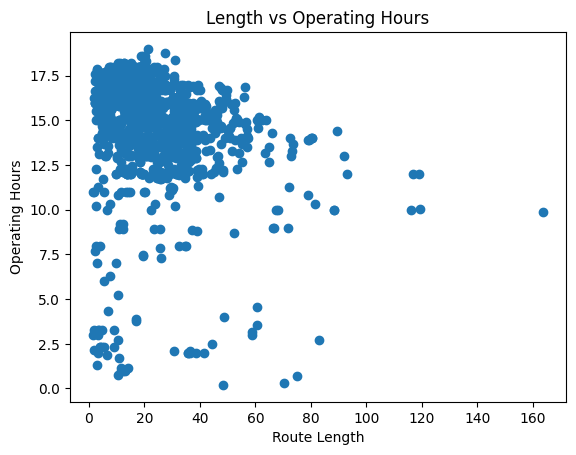

,length,start_time,end_time,operating_hours
464,163.840,640.0,1630.0,9.90
3996,119.199,600.0,1605.0,10.05
2007,118.972,500.0,1700.0,12.00
1004,116.766,530.0,1730.0,12.00
707,116.115,700.0,1700.0,10.00


In [30]:
plt.scatter(df['length'], df['operating_hours'])
plt.xlabel("Route Length")
plt.ylabel("Operating Hours")
plt.title("Length vs Operating Hours")
plt.show()

df[['length', 'operating_hours']].corr()

df.sort_values(by='length', ascending=False).head()

### 🔍 What I’m Trying to Understand

From the previous analysis, I found that most routes operate around 14–17 hours per day.

Now I’m curious:

Does the length of a route influence how long it operates?

In other words:
- Do longer routes operate longer?
- Or are shorter routes more active throughout the day?

### 🧠 Why This Matters

Understanding this relationship can reveal how the transport system is structured:

- If longer routes operate longer → system prioritizes coverage  
- If shorter routes operate longer → system prioritizes high-demand areas  

This helps distinguish between:
core mobility vs connectivity routes

### ⚙️ Approach

To explore this, I use:

1. Scatter plot → to visually inspect the relationship  
2. Correlation → to measure the strength of the relationship numerically  
3. Sorting → to examine extreme cases (longest routes)

### 📊 Result

From the scatter plot:

- Most routes are concentrated between **10–18 operating hours**, regardless of route length  
- The majority of routes have lengths below ~50 km, forming a dense cluster  
- There is no clear upward or downward trend between route length and operating hours  

Additionally:

- Some very long routes (>100 km) still operate only around **9–12 hours**  
- A few short routes have very low operating hours, appearing as outliers  

### 💡 Insight

Operating hours do not appear to strongly depend on route length.

Even though route lengths vary significantly, most routes operate within a similar time range.

This suggests that:

- Transport operations are not driven by distance alone  
- Instead, they are likely influenced by demand patterns and service design  

Shorter routes tend to cluster around longer operating hours,
indicating that they may serve high-demand urban areas.

### 🔄 Reflection

At first, I expected longer routes to operate longer.

However, the scatter plot shows that this is not the case.

This reinforces the importance of validating assumptions using data rather than intuition.

In [31]:
print("Average length:", df['length'].mean())
print("Average hours:", df['operating_hours'].mean())

Average length: 21.753052558782848
Average hours: 14.918374827109265


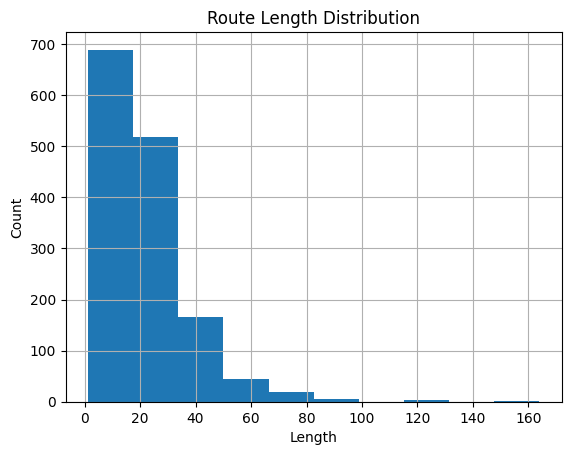

,length
count,1446.000000
mean,21.753053
std,15.863816
min,1.307000
25%,11.153750
50%,18.126500
75%,28.841500
max,163.840000


In [32]:
df['length'].hist()
plt.title("Route Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

df['length'].describe()

In [33]:
pd.cut(df['length'], bins=[0,20,50,200]).value_counts()

,count
length,
"(0, 20]",812
"(20, 50]",560
"(50, 200]",74


In [34]:
df['length_group'] = pd.cut(df['length'], bins=[0, 20, 50, 200])

df.groupby('length_group')['operating_hours'].mean()

/tmp/ipykernel_19014/1288412491.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('length_group')['operating_hours'].mean()


,operating_hours
length_group,
"(0, 20]",15.490012
"(20, 50]",14.439875
"(50, 200]",12.266892


/tmp/ipykernel_19014/2859900488.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ax = df.groupby('length_group')['operating_hours'].mean().plot(kind='bar')
/tmp/ipykernel_19014/2859900488.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, v in enumerate(df.groupby('length_group')['operating_hours'].mean()):


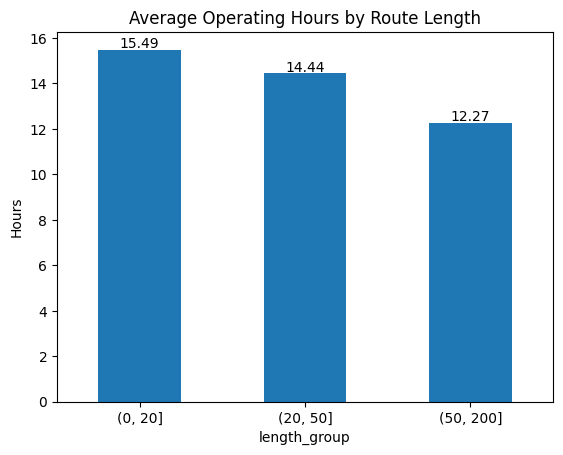

In [35]:
ax = df.groupby('length_group')['operating_hours'].mean().plot(kind='bar')

for i, v in enumerate(df.groupby('length_group')['operating_hours'].mean()):
    ax.text(i, v + 0.1, f"{v:.2f}", ha='center')

plt.title("Average Operating Hours by Route Length")
plt.ylabel("Hours")
plt.xticks(rotation=0)
plt.show()

### 🔍 What I’m Trying to Understand

From the scatter plot, the relationship between route length and operating hours is not very clear.

The data points are widely scattered, making it difficult to identify a strong pattern.

To better understand this relationship, I need a way to simplify the data.

### 🧠 Why Grouping is Needed

Instead of looking at individual data points,
I group routes into categories (short, medium, long).

This helps:
- reduce noise in the data  
- make patterns easier to observe  
- compare groups more clearly  

However, grouping should not be arbitrary.
It needs to be based on how the data is distributed.

### 📊 Understanding Route Length Distribution

Before defining categories, I examine the distribution of route lengths.

From the histogram and summary statistics:

- Median ≈ 18 km  
- 75% of routes are below ~30 km  
- A small number of routes extend beyond 100 km  

This shows that most routes are relatively short,
with a long tail of longer routes.

### ⚙️ Defining Route Length Categories

Based on the distribution, I define:

- 0–20 km → short routes  
- 20–50 km → medium routes  
- 50+ km → long routes  

These thresholds are not arbitrary —
they are guided by the observed distribution of the data.

### 💡 Why This Step Matters

The goal is to transform a noisy relationship into a clearer comparison.

By grouping routes, I can now compare:

“How does operating time differ across route types?”

This makes the analysis more interpretable than relying on scatter plots alone.

## 🎯 **Final Insights** 🎯

### 1. Operating Duration

Most routes operate between **14–17 hours per day**.

This indicates that the transport system is active for most of the day,
supporting continuous urban mobility.

---

### 2. Route Structure

The majority of routes are relatively short (below ~50 km),
with only a small number of long-distance routes.

This suggests a system focused on **intra-city movement** rather than long-distance travel.

---

### 3. Relationship Between Length and Operating Hours

Shorter routes tend to operate longer,
while longer routes operate for shorter durations.

This implies:

- Short routes serve as **core mobility backbone**
- Long routes function as **connectivity links**

---

### 4. System Insight

Transport operations appear to be driven more by **demand patterns**
rather than physical distance.

This reflects a system optimized for **urban activity concentration**.

## ⚠️ Limitations

- Only routes with valid time data (~36%) are included  
- Overnight routes are excluded due to model limitations  
- Time calculation is approximated  
- Spatial analysis is not included  

This means the results primarily reflect **same-day operational patterns**

## 🔄 Next Step

The current model does not account for overnight routes.

In the next phase, I will:

- Handle cross-day operations  
- Improve time calculation accuracy  
- Re-evaluate the distribution  

This will provide a more complete understanding of transport behavior.